# 02 · Physics nowcasts of every product

`run.py physics`: persistence, extrapolation, S-PROG and STEPS (pysteps, `core.nowcast`) of
the radar, the sensor maps and the adjusted radar, every 30 minutes of the test weeks,
along each product's own motion and along the radar's. Scores from `results/`.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")       # torch + pysteps in one process (macOS)
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "projects" / "multisensor_nowcasting" / "src"))
RES = ROOT / "projects" / "multisensor_nowcasting" / "results"
from multisensor_nowcasting.settings import NETWORKS
from multisensor_nowcasting.cube import Cube
from multisensor_nowcasting.report import label
NETS = [n for n in NETWORKS if Cube.exists(n)]
plt.rcParams.update({"figure.dpi": 72, "axes.titlesize": 10})
pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
NETS = [n for n in NETS if (RES / f"scores_{n}.csv").exists()]
print("networks with results:", NETS)

networks with results: ['openmrg', 'openmesh']


In [2]:
for net in NETS:
    sc = pd.read_csv(RES / f"scores_{net}.csv")
    phys = sc[~sc.forecast.str.startswith("learned") & (sc.region == "domain")]
    t = phys.pivot_table(index="forecast", columns="lead_min", values="CSI_1")[[15, 30, 60]]
    t["MAE 60"] = phys[phys.lead_min == 60].set_index("forecast")["MAE"]
    t["FSS 10 km, 60"] = phys[phys.lead_min == 60].set_index("forecast")["FSS_10km"]
    print(NETWORKS[net].label, "- CSI at 1 mm/h against the radar")
    print(t.sort_values(60, ascending=False).round(3), "\n")

Gothenburg (OpenMRG + OpenMRG2), JJA 2015 - CSI at 1 mm/h against the radar
lead_min                      15     30     60  MAE 60  FSS 10 km, 60
forecast                                                             
R|steps_mean               0.558  0.471  0.360   0.528          0.706
R|sprog                    0.584  0.484  0.353   0.650          0.682
R|extrapolation            0.585  0.474  0.346   0.583          0.711
RC|sprog_Rmotion           0.405  0.372  0.304   0.733          0.596
RCP|sprog_Rmotion          0.408  0.373  0.303   0.726          0.594
RC|extrapolation_Rmotion   0.420  0.375  0.296   0.671          0.623
RCP|extrapolation_Rmotion  0.421  0.375  0.296   0.662          0.628
RP|sprog_Rmotion           0.432  0.382  0.294   0.710          0.607
RP|extrapolation_Rmotion   0.439  0.379  0.291   0.650          0.635
CP|sprog_Rmotion           0.343  0.318  0.262   0.661          0.525
CP|extrapolation_Rmotion   0.345  0.322  0.260   0.635          0.535
C|sprog_Rmotio

## Own motion or the radar's?

For each sensor product, the extrapolation along its own Lucas-Kanade motion and along the
radar's, by lead time.

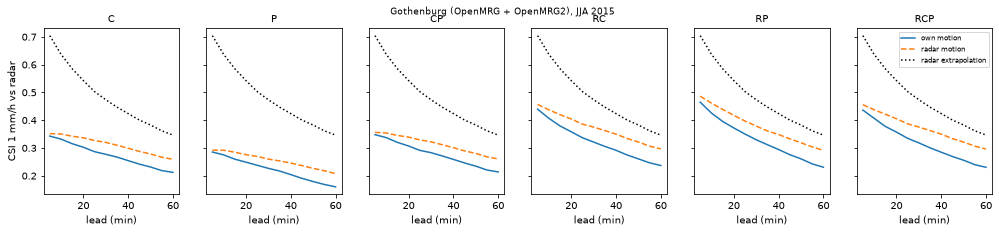

mean difference between each product's motion and the radar's (km/h):
         C     P    CP    RC    RP   RCP
km/h  42.4  95.4  48.0  19.1  26.7  20.8


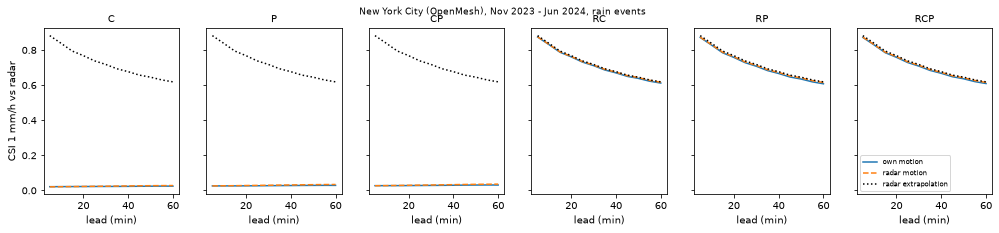

mean difference between each product's motion and the radar's (km/h):
         C     P    CP   RC   RP  RCP
km/h  63.3  68.8  65.7  3.3  3.5  3.5


In [3]:
for net in NETS:
    sc = pd.read_csv(RES / f"scores_{net}.csv")
    fig, axes = plt.subplots(1, 6, figsize=(17, 3), sharey=True)
    for ax, p in zip(axes, ["C", "P", "CP", "RC", "RP", "RCP"]):
        for fid, ls in ((f"{p}|extrapolation", "-"), (f"{p}|extrapolation_Rmotion", "--")):
            q = sc[(sc.forecast == fid) & (sc.region == "domain")].sort_values("lead_min")
            ax.plot(q.lead_min, q.CSI_1, ls, label="own motion" if ls == "-" else "radar motion")
        q = sc[(sc.forecast == "R|extrapolation") & (sc.region == "domain")].sort_values("lead_min")
        ax.plot(q.lead_min, q.CSI_1, ":k", label="radar extrapolation")
        ax.set_title(p); ax.set_xlabel("lead (min)")
    axes[0].set_ylabel("CSI 1 mm/h vs radar"); axes[-1].legend(fontsize=7)
    fig.suptitle(NETWORKS[net].label, fontsize=9)
    plt.show()
    m = RES / f"motion_{net}.csv"
    if m.exists():
        print("mean difference between each product's motion and the radar's (km/h):")
        print(pd.read_csv(m).drop(columns="issue").mean().round(1).to_frame("km/h").T)

## At the gauges, and the ensembles

In [4]:
for net in NETS:
    ga = pd.read_csv(RES / f"gauges_{net}.csv")
    g = ga[~ga.forecast.str.startswith("learned")]
    print(NETWORKS[net].label, "- next-hour totals at the gauges")
    print(g[g.what == "next-hour total"].set_index("forecast")[["n", "RMSE", "corr", "bias"]].sort_values("RMSE").round(3))
    c = RES / f"crps_{net}.csv"
    if c.exists():
        print(pd.read_csv(c).pivot_table(index="product", columns=["where", "lead_min"], values="CRPS").round(3), "\n")

Gothenburg (OpenMRG + OpenMRG2), JJA 2015 - next-hour totals at the gauges
                              n   RMSE   corr   bias
forecast                                            
CP|steps_mean              6397  1.015  0.651 -0.172
RCP|extrapolation_Rmotion  6397  1.020  0.661 -0.142
CP|extrapolation_Rmotion   6397  1.023  0.658 -0.170
RC|extrapolation_Rmotion   6397  1.026  0.660 -0.115
C|extrapolation_Rmotion    6397  1.028  0.655 -0.168
RCP|steps_mean             6397  1.034  0.639 -0.038
CP|sprog_Rmotion           6397  1.047  0.653 -0.112
RC|extrapolation           6397  1.058  0.650 -0.046
C|sprog_Rmotion            6397  1.059  0.647 -0.103
RCP|extrapolation          6397  1.073  0.634 -0.080
RP|extrapolation_Rmotion   6397  1.099  0.595 -0.281
R|steps_mean               6397  1.110  0.575 -0.272
P|extrapolation_Rmotion    6397  1.128  0.569 -0.490
RCP|sprog_Rmotion          6397  1.136  0.637 -0.000
P|sprog_Rmotion            6397  1.146  0.564 -0.390
RC|sprog_Rmotion        

New York City (OpenMesh), Nov 2023 - Jun 2024, rain events - next-hour totals at the gauges
                              n   RMSE   corr   bias
forecast                                            
RCP|steps_mean             2060  1.739  0.799 -0.147
RCP|extrapolation          2060  1.749  0.775 -0.034
RCP|sprog_Rmotion          2060  1.756  0.775 -0.069
RCP|sprog                  2060  1.762  0.776 -0.056
RP|sprog_Rmotion           2060  1.773  0.775 -0.054
RP|sprog                   2060  1.779  0.778 -0.036
RCP|extrapolation_Rmotion  2060  1.784  0.764 -0.041
RP|extrapolation           2060  1.808  0.767  0.003
RC|extrapolation_Rmotion   2060  1.808  0.758 -0.132
RC|extrapolation           2060  1.834  0.749 -0.131
RP|extrapolation_Rmotion   2060  1.857  0.751 -0.013
R|extrapolation            2060  1.877  0.737 -0.156
R|sprog                    2060  1.882  0.740 -0.197
CP|extrapolation           2060  1.900  0.771  0.010
R|steps_mean               2060  1.926  0.766 -0.224
RC|spro